[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YangKCLab/social-media-analysis/blob/main/docs/topics/visualization/report-figure.ipynb)

# From a default plot to a figure for a report

A plot with the default settings of Matplotlib is not ready for a report.
This notebook starts with a default plot and changes it in five steps: labels, fewer elements, figure size and font size, color, and export.
Each step applies one principle of figure design.
The last section has the complete code in one cell.

The data is invented.
The notebook generates the number of posts per day on three platforms, so the figure shows no real finding.

Sections: The message and the data, The default plot, Step 1: labels, Step 2: fewer elements, Step 3: figure size and font size, Step 4: color, Step 5: export as PDF and PNG, The complete code.

Packages beyond the standard library: `matplotlib`, `numpy`, `pandas`, `scicolor`.
Install them with `uv add matplotlib numpy pandas scicolor` (or `pip install`).
Colab has all of them except `scicolor`, and the next cell installs it there.

In [1]:
# Colab does not have scicolor, so this cell installs it there.
# pip may print a note about restarting the kernel. A restart is not needed.
# The cell does nothing if scicolor is already installed.
import importlib.util

if importlib.util.find_spec("scicolor") is None:
    %pip install -q scicolor

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scicolor
from IPython.display import Image, display
from matplotlib.colors import to_hex

## The message and the data

Write the message of a figure as one sentence before you make the figure.
Then choose the figure type, the order of the items, and the colors that make the sentence easy to see.

The message of this figure: **Platform B grew during the 30 days and passed platform C. Platform A and platform C did not grow.**

The message is about a change over time, so the figure is a line plot with one line for each platform.

In [3]:
# Invented data: the number of posts per day on three platforms for 30 days.
rng = np.random.default_rng(415)
day = np.arange(1, 31)
posts = pd.DataFrame({
    "day": day,
    "platform_a": 300 + 40 * np.sin(2 * np.pi * day / 7) + rng.normal(0, 15, size=30),
    "platform_b": 100 + 4 * day + rng.normal(0, 12, size=30),
    "platform_c": 180 + rng.normal(0, 12, size=30),
}).round().astype(int)
posts.head()

,day,platform_a,platform_b,platform_c
0,1,332,113,184
1,2,360,110,162
2,3,299,117,190
3,4,296,112,190
4,5,251,119,178


The table has 30 rows, one for each day, and 4 columns.
Each platform column holds the number of posts on that day.

| | day | platform_a | platform_b | platform_c |
| --- | --- | --- | --- | --- |
| 0 | 1 | 332 | 113 | 184 |
| 1 | 2 | 360 | 110 | 162 |
| 2 | 3 | 299 | 117 | 190 |
| 3 | 4 | 296 | 112 | 190 |
| 4 | 5 | 251 | 119 | 178 |

The seed 415 makes the random numbers the same in every run.

## The default plot

The first plot uses the default settings of Matplotlib.
`label=column` gives each line its column name as the legend entry.

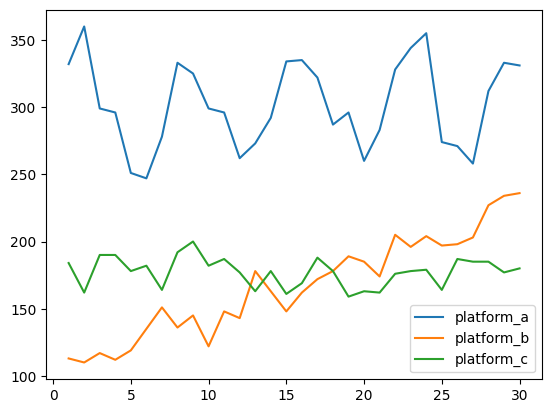

In [4]:
fig, ax = plt.subplots()
for column in ["platform_a", "platform_b", "platform_c"]:
    ax.plot(posts["day"], posts[column], label=column)
ax.legend()
plt.show()

The plot shows the three lines, and the reader still misses several things:

- The axes have no labels, so the reader does not know what the numbers are.
- The legend shows the column names of the table, such as `platform_a`. A column name is written for code, not for a reader.

The five steps below fix these two points and several others.

## Step 1: labels

Always label a figure.
Give each axis a label, and include the unit.
Write the legend entries in plain words.
The `label` argument of `ax.plot` sets the legend entry of a line.

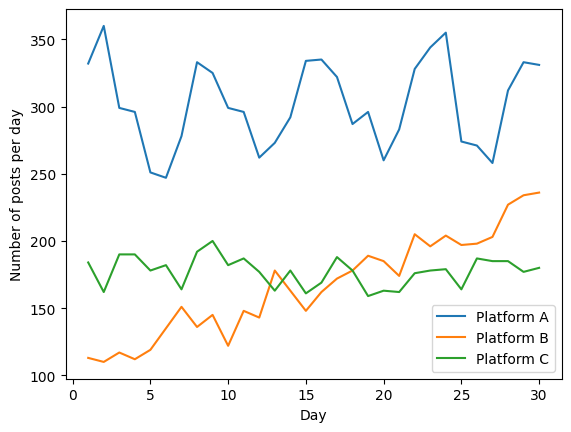

In [5]:
labels = {"platform_a": "Platform A", "platform_b": "Platform B", "platform_c": "Platform C"}

fig, ax = plt.subplots()
for column, label in labels.items():
    ax.plot(posts["day"], posts[column], label=label)
ax.set_xlabel("Day")
ax.set_ylabel("Number of posts per day")
ax.legend()
plt.show()

The y-axis label says what is counted and for which period: posts per day.

A figure in a report also needs a caption.
The caption is part of the text of the report and not part of the figure.
For this reason the figure has no title: a title would repeat the caption.

## Step 2: fewer elements

Keep the figure simple: include only the elements that the message needs.
The top border and the right border of the plot carry no information.
The frame around the legend carries none either.
`ax.spines` holds the four borders of the plot.

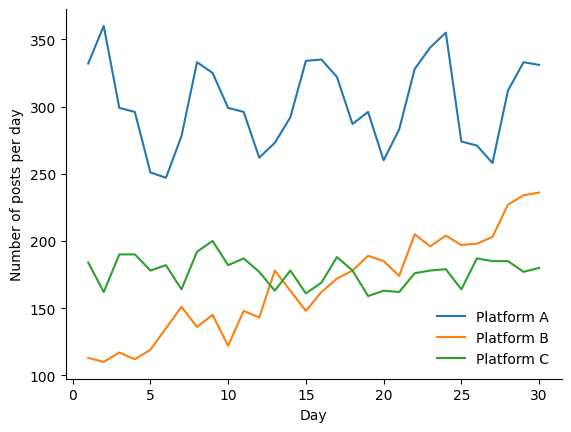

In [6]:
fig, ax = plt.subplots()
for column, label in labels.items():
    ax.plot(posts["day"], posts[column], label=label)
ax.set_xlabel("Day")
ax.set_ylabel("Number of posts per day")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

The left border and the bottom border stay, because they carry the tick marks and the numbers.

## Step 3: figure size and font size

The text in a figure should be as large as the text around the figure, or larger.
The text gets too small when a large figure is shrunk to fit the page.
So create the figure in the size that it has in the report, and then set the font size.

The figure of step 2 has the default size of Matplotlib: 6.4 inches wide and 4.8 inches high.
Suppose that the figure is 4 inches wide in the report and that the text of the report has 10 points.

The next cell saves the figure of step 2 as it is, for a comparison below.

In [7]:
os.makedirs("output", exist_ok=True)
# The figure of step 2 has the default size, 6.4 by 4.8 inches.
fig.savefig("output/step2.png", dpi=300)

The next cell draws the figure again with a size of 4 by 3 inches and saves it too.
`figsize` is in inches, and `font.size` is in points.
The default font size of Matplotlib is also 10 points, so the first line changes nothing here.
Change the number if the text of your report has another size.

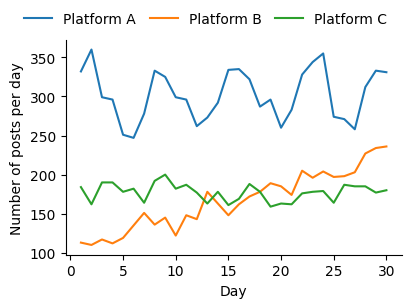

In [8]:
plt.rcParams["font.size"] = 10
fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
for column, label in labels.items():
    ax.plot(posts["day"], posts[column], label=label)
ax.set_xlabel("Day")
ax.set_ylabel("Number of posts per day")
ax.spines[["top", "right"]].set_visible(False)
fig.legend(frameon=False, loc="outside upper center", ncols=3, columnspacing=1)
fig.savefig("output/step3.png", dpi=300)
plt.show()

The cell has two more changes, and both come from the smaller size:

- `layout="constrained"` tells Matplotlib to move the plot so that the labels fit inside the figure. Without it, most of the x-axis label of a figure of this size is below the lower edge of the saved file. The notebook does not show this problem, because it crops every figure to its content before it shows the figure.
- The legend is above the plot, in one row. In a figure of this size, a legend inside the plot covers a part of the lines. `fig.legend` with `loc="outside upper center"` puts the legend above the plot, and the constrained layout makes room for it. `ncols=3` puts the three entries in one row. `columnspacing=1` moves the entries closer together, so that the row fits into 4 inches.

The next cell shows both saved files with a width of 400 pixels.
This is how they compare when both are 4 inches wide in a report.

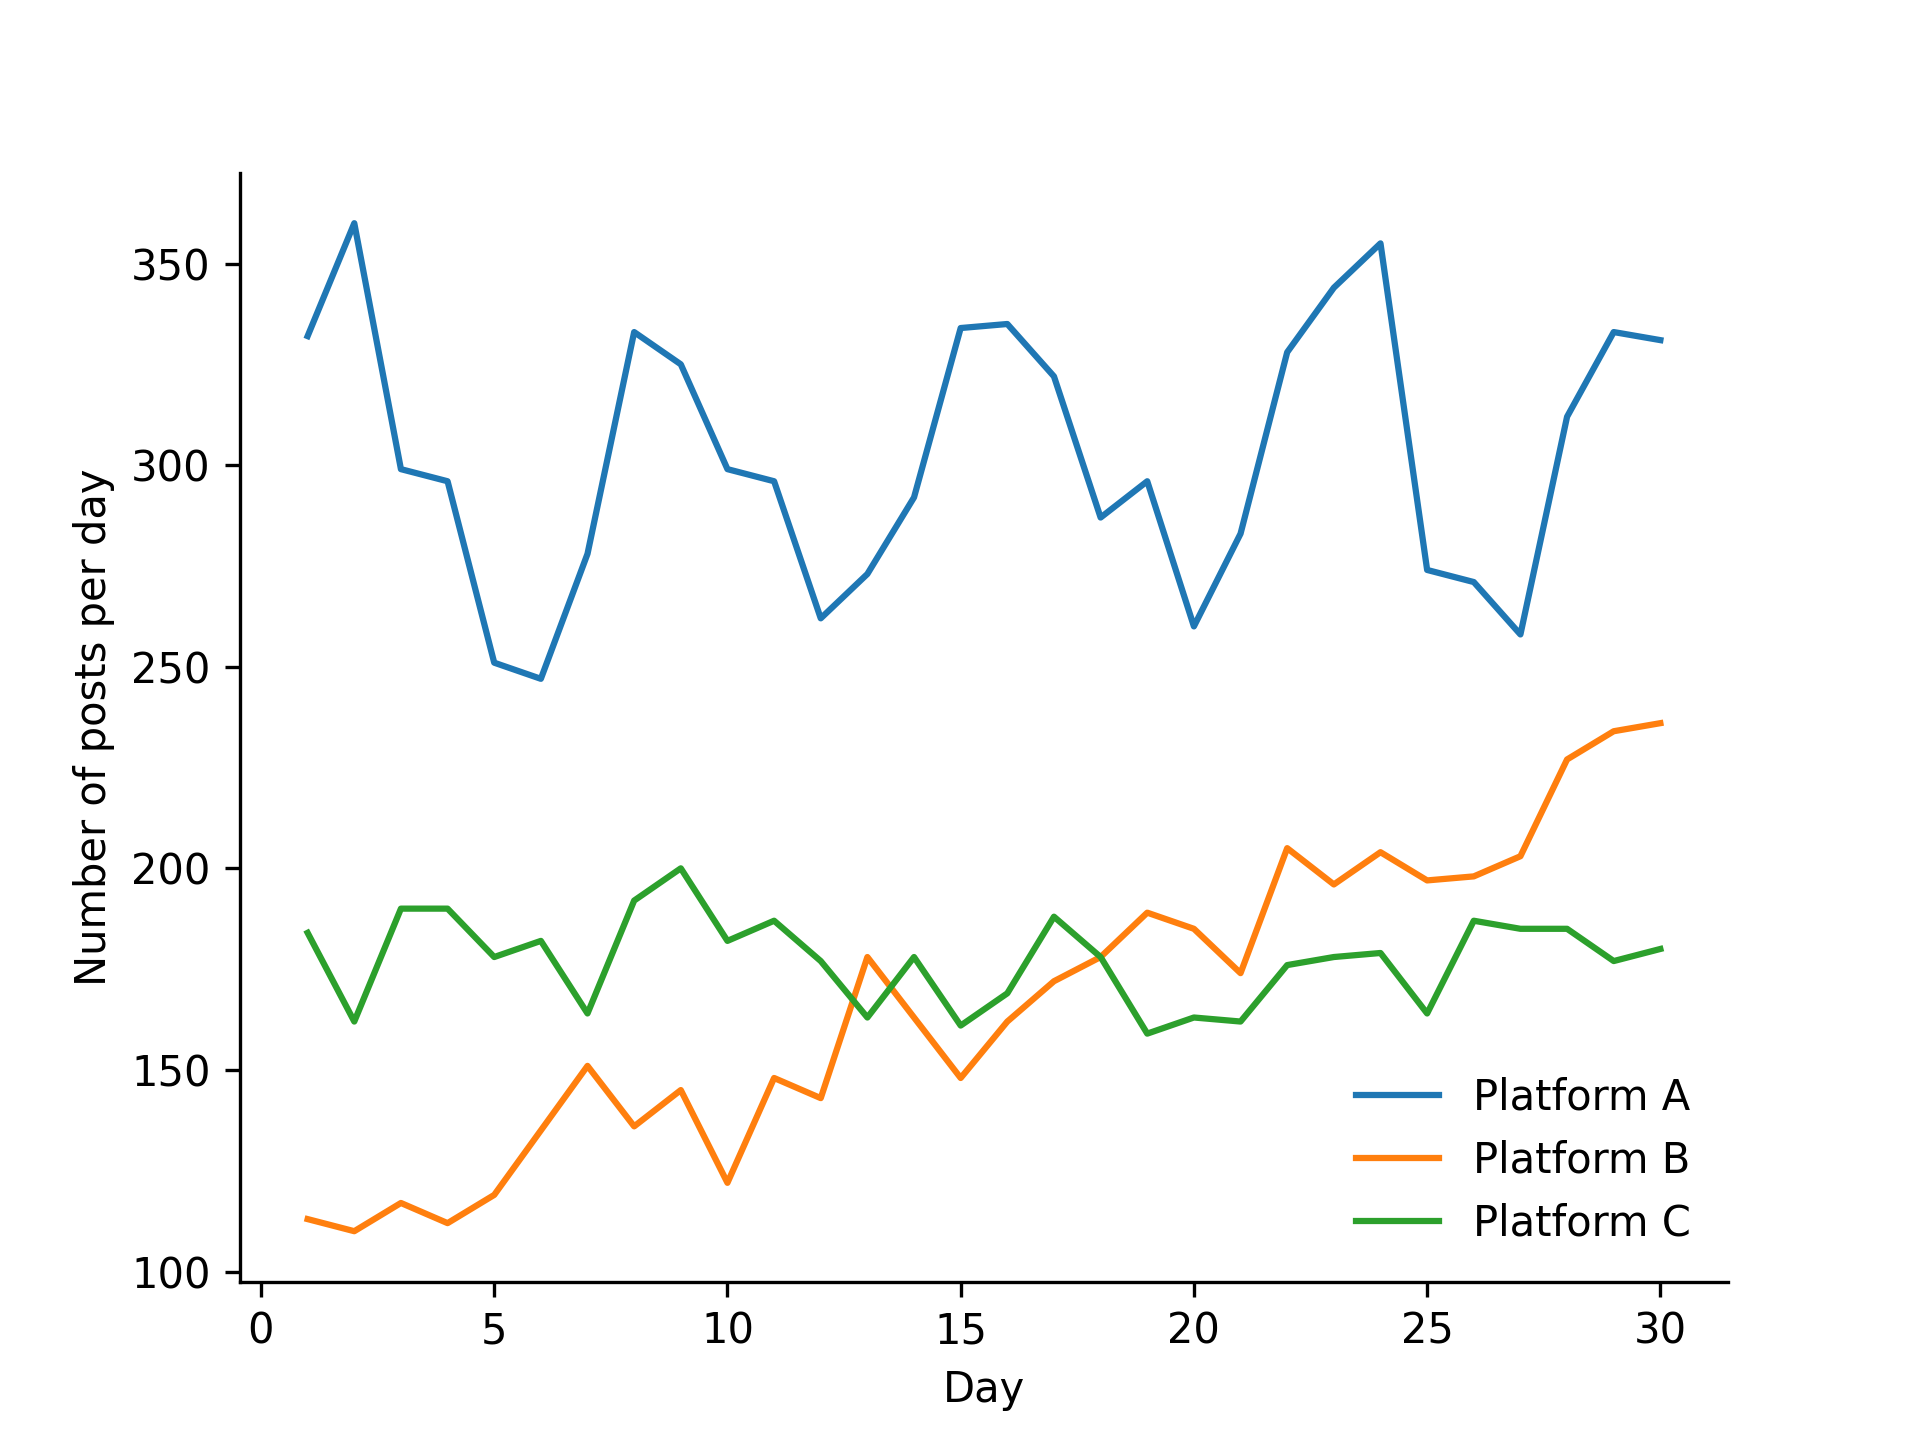

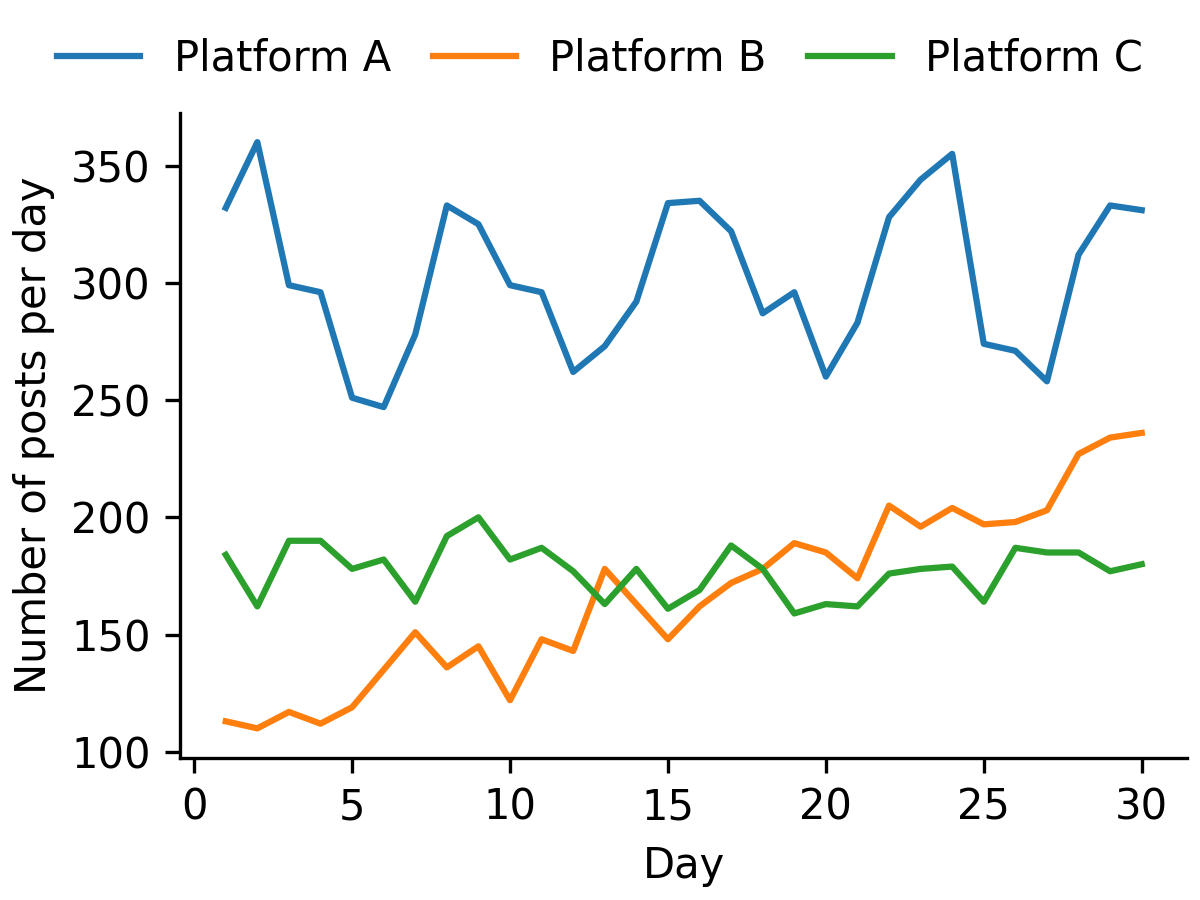

In [9]:
# Both files, as wide as they are in the report (400 pixels stand for 4 inches).
display(Image("output/step2.png", width=400))
display(Image("output/step3.png", width=400))

The first image is the figure of step 2.
It was made 6.4 inches wide, so it is shrunk to fit a width of 4 inches.
Its 10-point text becomes 6.25-point text (10 × 4 / 6.4), which is much smaller than the text of the report.
Its lines get thinner too.

The second image is the figure of step 3.
It was made 4 inches wide, so its text stays at 10 points.

## Step 4: color

The default colors of Matplotlib are blue, orange, and green.
Take the colors from a color-blind friendly color map instead.

`batlowS` is a categorical color map of the Scicolor package: a list of colors for groups that have no order.
The next cell shows its first four colors as hex codes.

In [10]:
cmap = scicolor.get_cmap("batlowS")
[to_hex(cmap(i)) for i in range(4)]

['#011959', '#faccfa', '#828231', '#226061']

The result is `['#011959', '#faccfa', '#828231', '#226061']`: a dark blue, a light pink, an olive green, and a dark teal.

A thin line in light pink is hard to see on a white background, so the figure does not use the second color.
Check every color against the background of the figure, also when the color map is color-blind friendly.

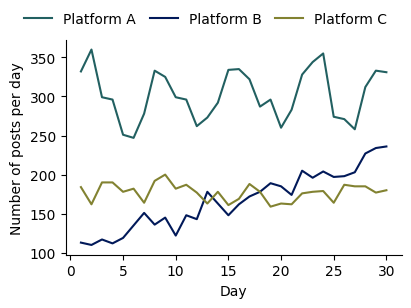

In [11]:
colors = {"platform_a": cmap(3), "platform_b": cmap(0), "platform_c": cmap(2)}

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
for column, label in labels.items():
    ax.plot(posts["day"], posts[column], label=label, color=colors[column])
ax.set_xlabel("Day")
ax.set_ylabel("Number of posts per day")
ax.spines[["top", "right"]].set_visible(False)
fig.legend(frameon=False, loc="outside upper center", ncols=3, columnspacing=1)
plt.show()

Platform B has the darkest color, because the message is about platform B.
The lines of platform B and platform C cross, and they have the two colors that differ the most: the dark blue and the olive green.

## Step 5: export as PDF and PNG

A raster file, such as a PNG or a JPEG file, stores pixels.
It gets blurred when it is enlarged.
A vector file, such as a PDF or an SVG file, stores shapes.
It stays sharp at every size.

Prefer a vector file for a report.
If you need a raster file, save it with 300 DPI (dots per inch).

In [12]:
fig.savefig("output/figure.pdf")
fig.savefig("output/figure.png", dpi=300)

The cell writes two files into the folder `output`.
The PDF file has one page of 4 by 3 inches.
The PNG file has 1200 by 900 pixels, which is 4 by 3 inches at 300 DPI.

Two notes on `savefig`:

- `fig.savefig` works in a later cell, because the name `fig` still refers to the figure of step 4. `plt.savefig` in a cell of its own saves an empty figure, because the notebook closes each figure at the end of the cell that draws it. In the cell that draws the figure, and in a script, both forms work.
- The calls have no `bbox_inches="tight"` argument. That argument crops the file to its content, so the file is no longer 4 by 3 inches.

The next cell shows the saved PNG file.

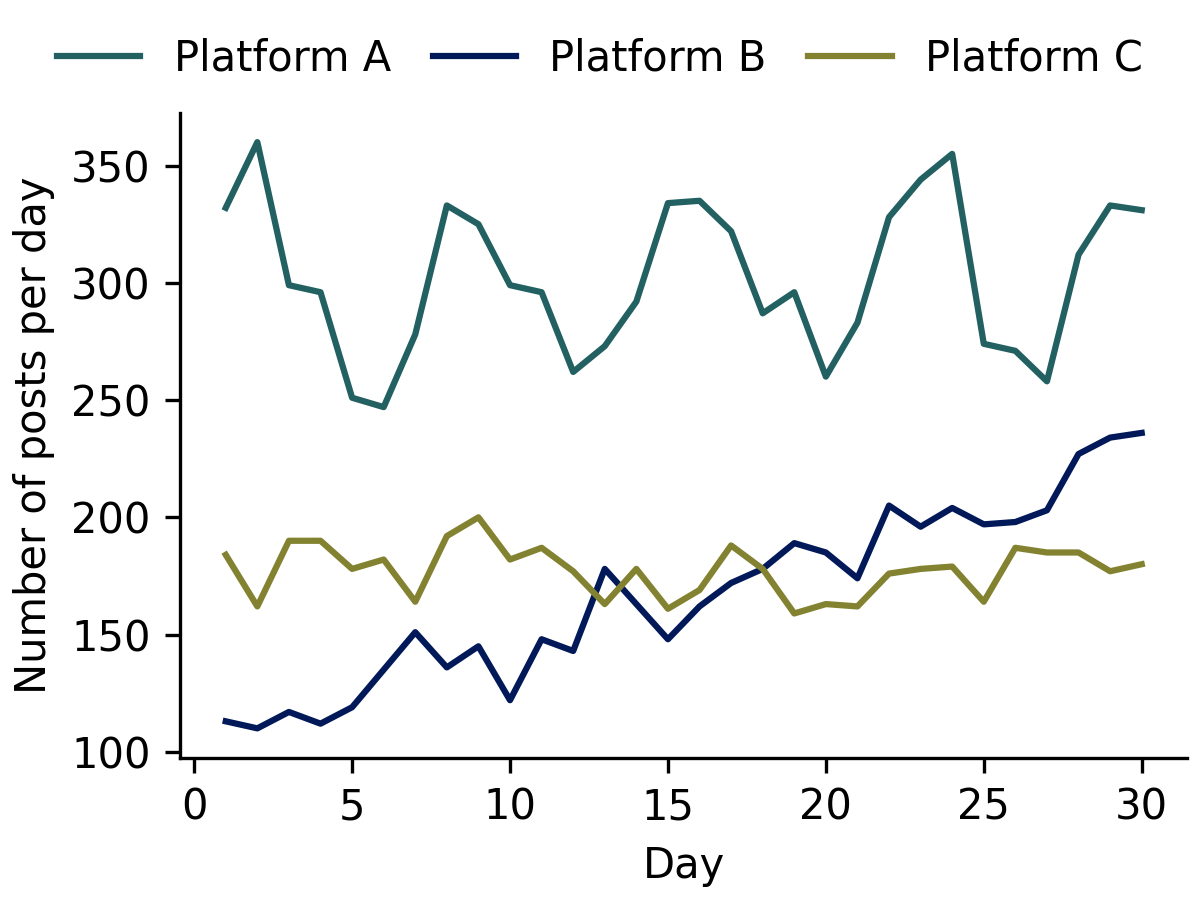

In [13]:
display(Image("output/figure.png", width=400))

This is the whole file, with its margins.
The figure that the notebook shows below the cell of step 4 is the same figure, cropped to its content.

## The complete code

The cell below has the data, the final figure, and the export in one place.
It runs on its own, so you can copy it into a script.
In your own figure, replace the data, the labels, the size, and the file names.

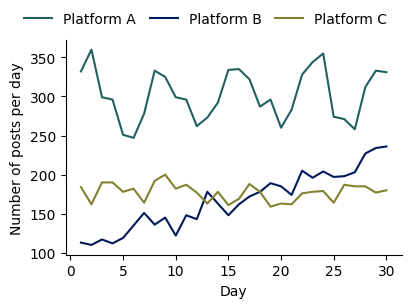

In [14]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scicolor

# Invented data: the number of posts per day on three platforms for 30 days.
rng = np.random.default_rng(415)
day = np.arange(1, 31)
posts = pd.DataFrame({
    "day": day,
    "platform_a": 300 + 40 * np.sin(2 * np.pi * day / 7) + rng.normal(0, 15, size=30),
    "platform_b": 100 + 4 * day + rng.normal(0, 12, size=30),
    "platform_c": 180 + rng.normal(0, 12, size=30),
}).round().astype(int)

labels = {"platform_a": "Platform A", "platform_b": "Platform B", "platform_c": "Platform C"}
cmap = scicolor.get_cmap("batlowS")
colors = {"platform_a": cmap(3), "platform_b": cmap(0), "platform_c": cmap(2)}

plt.rcParams["font.size"] = 10
fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
for column, label in labels.items():
    ax.plot(posts["day"], posts[column], label=label, color=colors[column])
ax.set_xlabel("Day")
ax.set_ylabel("Number of posts per day")
ax.spines[["top", "right"]].set_visible(False)
fig.legend(frameon=False, loc="outside upper center", ncols=3, columnspacing=1)

os.makedirs("output", exist_ok=True)
fig.savefig("output/figure.pdf")
fig.savefig("output/figure.png", dpi=300)
plt.show()

The two `savefig` lines are in the cell that draws the figure, before `plt.show()`.